In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table


## Setup Spark Session 

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 04:08:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
pd.set_option('display.max_columns', None) ## to see all columns
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (10, 4)

In [5]:
loans       = spark.read.csv("data/lms_loan_daily.csv",     header=True, inferSchema=True)
attributes  = spark.read.csv("data/features_attributes.csv", header=True, inferSchema=True)
financials  = spark.read.csv("data/features_financials.csv", header=True, inferSchema=True)
clickstream = spark.read.csv("data/feature_clickstream.csv", header=True, inferSchema=True)

# .count() in Spark requires a full scan, so it actually runs the job
print(f"loans       : {loans.count():>7,} rows × {len(loans.columns):>2} cols")
print(f"attributes  : {attributes.count():>7,} rows × {len(attributes.columns):>2} cols")
print(f"financials  : {financials.count():>7,} rows × {len(financials.columns):>2} cols")
print(f"clickstream : {clickstream.count():>7,} rows × {len(clickstream.columns):>2} cols")

loans       : 137,500 rows × 11 cols
attributes  :  12,500 rows ×  6 cols
financials  :  12,500 rows × 22 cols
clickstream : 215,376 rows × 22 cols


In [7]:
print("=== SCHEMA ===")
attributes.printSchema()

print("\n=== FIRST 10 ROWS ===")
attributes.show(10, truncate=False)

=== SCHEMA ===
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)


=== FIRST 10 ROWS ===
+-----------+----------------+---+-----------+-------------+-------------+
|Customer_ID|Name            |Age|SSN        |Occupation   |snapshot_date|
+-----------+----------------+---+-----------+-------------+-------------+
|CUS_0x1000 |Alistair Barrf  |18 |913-74-1218|Lawyer       |2023-05-01   |
|CUS_0x1009 |Arunah          |26 |063-67-6938|Mechanic     |2025-01-01   |
|CUS_0x100b |Shirboni        |19 |#F%$D@*&8  |Media_Manager|2024-03-01   |
|CUS_0x1011 |Schneyerh       |44 |793-05-8223|Doctor       |2023-11-01   |
|CUS_0x1013 |Cameront        |44 |930-49-9615|Mechanic     |2023-12-01   |
|CUS_0x1015 |Holtono         |27 |810-97-7024|Journalist   |2023-08-01   |
|CUS_0x1018 |Felsenthalq     |15 |731-19-8119|A

In [8]:
print("=== NULL COUNTS PER COLUMN ===")
attributes.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in attributes.columns
]).show()

print("=== DISTINCT VALUE COUNTS PER COLUMN ===")
attributes.select([F.countDistinct(c).alias(c) for c in attributes.columns]).show()

print("=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===")
attributes.groupBy("SSN").count().orderBy(F.desc("count")).show(10, truncate=False)

=== NULL COUNTS PER COLUMN ===
+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+

=== DISTINCT VALUE COUNTS PER COLUMN ===


+-----------+-----+---+-----+----------+-------------+
|Customer_ID| Name|Age|  SSN|Occupation|snapshot_date|
+-----------+-----+---+-----+----------+-------------+
|      12500|10139|301|11798|        16|           25|
+-----------+-----+---+-----+----------+-------------+

=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===
+-----------+-----+
|SSN        |count|
+-----------+-----+
|#F%$D@*&8  |703  |
|706-59-9144|1    |
|508-88-3060|1    |
|564-87-3414|1    |
|118-02-3131|1    |
|808-03-9422|1    |
|595-90-1107|1    |
|571-04-7703|1    |
|154-09-5858|1    |
|942-65-9443|1    |
+-----------+-----+
only showing top 10 rows



In [9]:
# Firist, investigate why so many unique age values
print("=== TOP 20 MOST COMMON RAW Age VALUES ===")
attributes.groupBy("Age").count().orderBy(F.desc("count")).show(20, truncate=False)

# Strip trailing underscore, then cast to int. invalid values become NULL.
attributes_age = attributes.withColumn(
    "Age_clean",
    F.regexp_replace(F.col("Age"), "_", "").cast(IntegerType())
)

print("=== Age_clean — descriptive stats ===")
attributes_age.select("Age_clean").describe().show()

print("=== Age_clean — outlier counts ===")
attributes_age.select(
    F.sum(F.when(F.col("Age_clean") < 0, 1).otherwise(0)).alias("age_below_0"),
    F.sum(F.when(F.col("Age_clean").between(0, 17), 1).otherwise(0)).alias("age_0_to_17"),
    F.sum(F.when(F.col("Age_clean").between(18, 100), 1).otherwise(0)).alias("age_18_to_100"),
    F.sum(F.when(F.col("Age_clean") > 100, 1).otherwise(0)).alias("age_above_100"),
    F.sum(F.when(F.col("Age_clean").isNull(), 1).otherwise(0)).alias("age_null_after_parse"),
).show()

=== TOP 20 MOST COMMON RAW Age VALUES ===
+---+-----+
|Age|count|
+---+-----+
|26 |364  |
|35 |361  |
|32 |360  |
|39 |360  |
|38 |345  |
|28 |343  |
|44 |343  |
|20 |342  |
|41 |340  |
|25 |340  |
|36 |339  |
|29 |336  |
|31 |336  |
|19 |336  |
|37 |333  |
|30 |330  |
|27 |326  |
|22 |326  |
|34 |325  |
|24 |320  |
+---+-----+
only showing top 20 rows

=== Age_clean — descriptive stats ===
+-------+-----------------+
|summary|        Age_clean|
+-------+-----------------+
|  count|            12500|
|   mean|        105.77184|
| stddev|664.5027048331665|
|    min|             -500|
|    max|             8678|
+-------+-----------------+

=== Age_clean — outlier counts ===
+-----------+-----------+-------------+-------------+--------------------+
|age_below_0|age_0_to_17|age_18_to_100|age_above_100|age_null_after_parse|
+-----------+-----------+-------------+-------------+--------------------+
|        104|        669|        11512|          215|                   0|
+-----------+-----

=== TOP 10 MOST COMMON Age_clean values BELOW 18 ===
+---------+-----+
|Age_clean|count|
+---------+-----+
|       17|  198|
|       15|  195|
|       16|  189|
|     -500|  104|
|       14|   87|
+---------+-----+

=== TOP 10 MOST COMMON Age_clean values ABOVE 100 ===
+---------+-----+
|Age_clean|count|
+---------+-----+
|      655|    2|
|     1990|    1|
|     2580|    1|
|     4929|    1|
|     8105|    1|
|     4391|    1|
|     3986|    1|
|     1265|    1|
|     3834|    1|
|     8678|    1|
+---------+-----+
only showing top 10 rows

=== TOP 10 MOST COMMON Age_clean values BELOW 0 ===
+---------+-----+
|Age_clean|count|
+---------+-----+
|     -500|  104|
+---------+-----+


=== AGE DISTRIBUTION (clipped to -100..200 for visibility) ===


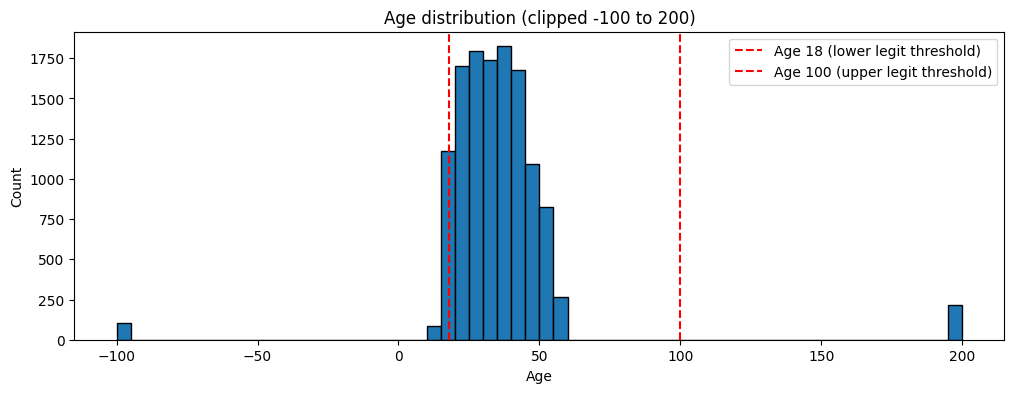

In [10]:
# Look at the extreme tails — what specific values appear?
print("=== TOP 10 MOST COMMON Age_clean values BELOW 18 ===")
attributes_age.filter(F.col("Age_clean") < 18) \
    .groupBy("Age_clean").count().orderBy(F.desc("count")).show(10)

print("=== TOP 10 MOST COMMON Age_clean values ABOVE 100 ===")
attributes_age.filter(F.col("Age_clean") > 100) \
    .groupBy("Age_clean").count().orderBy(F.desc("count")).show(10)

print("=== TOP 10 MOST COMMON Age_clean values BELOW 0 ===")
attributes_age.filter(F.col("Age_clean") < 0) \
    .groupBy("Age_clean").count().orderBy(F.desc("count")).show(10)

# Visualize the valid-range distribution
print("\n=== AGE DISTRIBUTION (clipped to -100..200 for visibility) ===")
ages_pd = attributes_age.select("Age_clean").toPandas()
plt.figure(figsize=(12, 4))
plt.hist(ages_pd["Age_clean"].clip(-100, 200), bins=60, edgecolor='black')
plt.title("Age distribution (clipped -100 to 200)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(18, color='red', linestyle='--', label='Age 18 (lower legit threshold)')
plt.axvline(100, color='red', linestyle='--', label='Age 100 (upper legit threshold)')
plt.legend()
plt.show()

In [11]:
print("=== ALL OCCUPATION VALUES (full count) ===")
attributes.groupBy("Occupation").count().orderBy(F.desc("count")).show(20, truncate=False)

=== ALL OCCUPATION VALUES (full count) ===
+-------------+-----+
|Occupation   |count|
+-------------+-----+
|_______      |880  |
|Lawyer       |828  |
|Architect    |795  |
|Engineer     |793  |
|Accountant   |791  |
|Scientist    |789  |
|Teacher      |782  |
|Media_Manager|780  |
|Developer    |780  |
|Mechanic     |780  |
|Entrepreneur |776  |
|Journalist   |761  |
|Doctor       |760  |
|Musician     |741  |
|Manager      |736  |
|Writer       |728  |
+-------------+-----+



In [12]:
print("=== SCHEMA ===")
financials.printSchema()

print("\n=== FIRST 5 ROWS (transposed for readability) ===")
# 22 columns is too wide to show normally, so use limit + toPandas + .T
financials.limit(5).toPandas().T

=== SCHEMA ===
root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payment_Behaviour: string (nullable = 

,0,1,2,3,4
Customer_ID,CUS_0x1000,CUS_0x1009,CUS_0x100b,CUS_0x1011,CUS_0x1013
Annual_Income,30625.94,52312.68_,113781.38999999998,58918.47,98620.98
Monthly_Inhand_Salary,2706.161667,4250.39,9549.7825,5208.8725,7962.415
Num_Bank_Accounts,6,6,1,3,3
Num_Credit_Card,5,5,4,3,3
Interest_Rate,27,17,1,17,6
Num_of_Loan,2,4,0,3,3
Type_of_Loan,"Credit-Builder Loan, and Home Equity Loan","Not Specified, Home Equity Loan, Credit-Builder Loan, and Payday Loan",None,"Student Loan, Credit-Builder Loan, and Debt Consolidation Loan","Student Loan, Debt Consolidation Loan, and Personal Loan"
Delay_from_due_date,57,5,14,27,12
Num_of_Delayed_Payment,26,18,8,13,9


In [15]:
print("=== NULL COUNTS PER COLUMN ===")
financials.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in financials.columns
]).toPandas().T.rename(columns={0: "null_count"})


=== NULL COUNTS PER COLUMN ===


,null_count
Customer_ID,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,1426
Delay_from_due_date,0
Num_of_Delayed_Payment,0


In [14]:
print("=== DISTINCT VALUE COUNTS PER COLUMN ===")
financials.select([F.countDistinct(c).alias(c) for c in financials.columns]) \
    .toPandas().T.rename(columns={0: "distinct_count"})

=== DISTINCT VALUE COUNTS PER COLUMN ===


,distinct_count
Customer_ID,12500
Annual_Income,12492
Monthly_Inhand_Salary,12490
Num_Bank_Accounts,174
Num_Credit_Card,284
Interest_Rate,300
Num_of_Loan,87
Type_of_Loan,6260
Delay_from_due_date,73
Num_of_Delayed_Payment,168


In [16]:
print("=== COUNT OF ROWS WITH UNDERSCORE IN STRING COLUMNS ===")
# Only check columns Spark inferred as string
string_cols = [c for c, t in financials.dtypes if t == 'string' and c != 'Customer_ID']
underscore_check = financials.select([
    F.sum(F.when(F.col(c).contains("_"), 1).otherwise(0)).alias(c)
    for c in string_cols
]).toPandas().T.rename(columns={0: "rows_with_underscore"})
underscore_check

=== COUNT OF ROWS WITH UNDERSCORE IN STRING COLUMNS ===


,rows_with_underscore
Annual_Income,859
Num_of_Loan,623
Type_of_Loan,0
Num_of_Delayed_Payment,374
Changed_Credit_Limit,254
Credit_Mix,2611
Outstanding_Debt,139
Credit_History_Age,0
Payment_of_Min_Amount,0
Amount_invested_monthly,558


In [17]:
print("=== Credit_Mix ===")
financials.groupBy("Credit_Mix").count().orderBy(F.desc("count")).show()

print("=== Payment_of_Min_Amount ===")
financials.groupBy("Payment_of_Min_Amount").count().orderBy(F.desc("count")).show()

print("=== Payment_Behaviour ===")
financials.groupBy("Payment_Behaviour").count().orderBy(F.desc("count")).show()

=== Credit_Mix ===
+----------+-----+
|Credit_Mix|count|
+----------+-----+
|  Standard| 4497|
|      Good| 3032|
|         _| 2611|
|       Bad| 2360|
+----------+-----+

=== Payment_of_Min_Amount ===
+---------------------+-----+
|Payment_of_Min_Amount|count|
+---------------------+-----+
|                  Yes| 6571|
|                   No| 4491|
|                   NM| 1438|
+---------------------+-----+

=== Payment_Behaviour ===
+--------------------+-----+
|   Payment_Behaviour|count|
+--------------------+-----+
|Low_spent_Small_v...| 3202|
|High_spent_Medium...| 2242|
|Low_spent_Medium_...| 1686|
|High_spent_Large_...| 1683|
|High_spent_Small_...| 1389|
|Low_spent_Large_v...| 1300|
|              !@9#%8|  998|
+--------------------+-----+



In [18]:
# Step 1: strip underscores from the 7 known dirty numeric columns and cast
strip_cols_float = ["Annual_Income", "Outstanding_Debt", "Changed_Credit_Limit",
                    "Amount_invested_monthly", "Monthly_Balance"]
strip_cols_int = ["Num_of_Loan", "Num_of_Delayed_Payment"]

financials_clean = financials
for c in strip_cols_float:
    financials_clean = financials_clean.withColumn(
        c, F.regexp_replace(F.col(c), "_", "").cast(FloatType())
    )
for c in strip_cols_int:
    financials_clean = financials_clean.withColumn(
        c, F.regexp_replace(F.col(c), "_", "").cast(IntegerType())
    )

# Step 2: describe ALL numeric columns
numeric_cols = [c for c, t in financials_clean.dtypes if t in ("int", "bigint", "float", "double")]
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}\n")

# Describe in chunks so the output fits
chunk = 6
for i in range(0, len(numeric_cols), chunk):
    print(f"=== Stats for cols {i+1}–{min(i+chunk, len(numeric_cols))} ===")
    financials_clean.select(numeric_cols[i:i+chunk]).describe().show()

Numeric columns (15): ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

=== Stats for cols 1–6 ===
+-------+------------------+---------------------+------------------+------------------+------------------+----------------+
|summary|     Annual_Income|Monthly_Inhand_Salary| Num_Bank_Accounts|   Num_Credit_Card|     Interest_Rate|     Num_of_Loan|
+-------+------------------+---------------------+------------------+------------------+------------------+----------------+
|  count|             12500|                12500|             12500|             12500|             12500|           12500|
|   mean|161620.55278140624|   4188.5923027131585|          16.93992|          23.17272|          73.21336|         3.099

In [19]:
# Look at the variety of formats first
print("=== TOP 10 UNIQUE Credit_History_Age VALUES ===")
financials.groupBy("Credit_History_Age").count().orderBy(F.desc("count")).show(10, truncate=False)

# Parse: "X Years and Y Months" → integer total months
parsed = financials.withColumn(
    "credit_hist_months",
    F.regexp_extract(F.col("Credit_History_Age"), r"(\d+) Years", 1).cast(IntegerType()) * 12
    + F.regexp_extract(F.col("Credit_History_Age"), r"(\d+) Months", 1).cast(IntegerType())
)

print("\n=== PARSED Credit_History_Age (as months) ===")
parsed.select("Credit_History_Age", "credit_hist_months").show(10, truncate=False)

print("\n=== Stats on parsed value ===")
parsed.select("credit_hist_months").describe().show()

print("\n=== NULL count after parsing ===")
parsed.select(F.sum(F.when(F.col("credit_hist_months").isNull(), 1).otherwise(0)).alias("nulls")).show()

=== TOP 10 UNIQUE Credit_History_Age VALUES ===
+----------------------+-----+
|Credit_History_Age    |count|
+----------------------+-----+
|16 Years and 2 Months |79   |
|19 Years and 5 Months |77   |
|19 Years and 9 Months |76   |
|16 Years and 0 Months |76   |
|18 Years and 10 Months|74   |
|19 Years and 4 Months |73   |
|18 Years and 2 Months |71   |
|18 Years and 5 Months |70   |
|17 Years and 10 Months|69   |
|20 Years and 0 Months |69   |
+----------------------+-----+
only showing top 10 rows


=== PARSED Credit_History_Age (as months) ===
+----------------------+------------------+
|Credit_History_Age    |credit_hist_months|
+----------------------+------------------+
|10 Years and 9 Months |129               |
|31 Years and 0 Months |372               |
|15 Years and 10 Months|190               |
|15 Years and 10 Months|190               |
|17 Years and 10 Months|214               |
|21 Years and 5 Months |257               |
|14 Years and 3 Months |171               |
|20 Y

In [20]:
# Quick look at the variety of formats
print("=== TOP 10 RAW Type_of_Loan VALUES ===")
financials.groupBy("Type_of_Loan").count().orderBy(F.desc("count")).show(10, truncate=False)

print(f"\nNULL Type_of_Loan rows: {financials.filter(F.col('Type_of_Loan').isNull()).count()}")
print(f"Total distinct combinations: {financials.select('Type_of_Loan').distinct().count()}")

=== TOP 10 RAW Type_of_Loan VALUES ===
+-----------------------+-----+
|Type_of_Loan           |count|
+-----------------------+-----+
|NULL                   |1426 |
|Not Specified          |176  |
|Credit-Builder Loan    |160  |
|Personal Loan          |159  |
|Debt Consolidation Loan|158  |
|Student Loan           |155  |
|Payday Loan            |150  |
|Mortgage Loan          |147  |
|Auto Loan              |144  |
|Home Equity Loan       |142  |
+-----------------------+-----+
only showing top 10 rows


NULL Type_of_Loan rows: 1426
Total distinct combinations: 6261


In [21]:
# Parse: split by ", " then strip leading "and " — gives an array of loan type strings
parsed_loans = financials.withColumn(
    "loan_types_array",
    F.split(F.col("Type_of_Loan"), ", ")
).withColumn(
    "loan_types_array",
    # remove "and " prefix from any element
    F.expr("transform(loan_types_array, x -> regexp_replace(x, '^and ', ''))")
)

print("=== SAMPLE PARSED ===")
parsed_loans.select("Type_of_Loan", "loan_types_array").show(5, truncate=False)

=== SAMPLE PARSED ===
+---------------------------------------------------------------------+-------------------------------------------------------------------+
|Type_of_Loan                                                         |loan_types_array                                                   |
+---------------------------------------------------------------------+-------------------------------------------------------------------+
|Credit-Builder Loan, and Home Equity Loan                            |[Credit-Builder Loan, Home Equity Loan]                            |
|Not Specified, Home Equity Loan, Credit-Builder Loan, and Payday Loan|[Not Specified, Home Equity Loan, Credit-Builder Loan, Payday Loan]|
|NULL                                                                 |NULL                                                               |
|Student Loan, Credit-Builder Loan, and Debt Consolidation Loan       |[Student Loan, Credit-Builder Loan, Debt Consolidation Loan]       

In [22]:
# Explode to one row per loan-type-per-customer to enumerate the distinct loan types
exploded = parsed_loans.select(F.explode("loan_types_array").alias("loan_type"))
print("=== ALL DISTINCT LOAN TYPES (with counts) ===")
exploded.groupBy("loan_type").count().orderBy(F.desc("count")).show(30, truncate=False)

=== ALL DISTINCT LOAN TYPES (with counts) ===
+-----------------------+-----+
|loan_type              |count|
+-----------------------+-----+
|Payday Loan            |5071 |
|Credit-Builder Loan    |5055 |
|Not Specified          |4952 |
|Home Equity Loan       |4888 |
|Student Loan           |4871 |
|Mortgage Loan          |4867 |
|Personal Loan          |4861 |
|Debt Consolidation Loan|4847 |
|Auto Loan              |4749 |
+-----------------------+-----+



In [8]:
print("=== NULL COUNTS PER COLUMN ===")
attributes.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in attributes.columns
]).show()

print("=== DISTINCT VALUE COUNTS PER COLUMN ===")
attributes.select([F.countDistinct(c).alias(c) for c in attributes.columns]).show()

print("=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===")
attributes.groupBy("SSN").count().orderBy(F.desc("count")).show(10, truncate=False)

=== NULL COUNTS PER COLUMN ===
+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+

=== DISTINCT VALUE COUNTS PER COLUMN ===


+-----------+-----+---+-----+----------+-------------+
|Customer_ID| Name|Age|  SSN|Occupation|snapshot_date|
+-----------+-----+---+-----+----------+-------------+
|      12500|10139|301|11798|        16|           25|
+-----------+-----+---+-----+----------+-------------+

=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===
+-----------+-----+
|SSN        |count|
+-----------+-----+
|#F%$D@*&8  |703  |
|706-59-9144|1    |
|508-88-3060|1    |
|564-87-3414|1    |
|118-02-3131|1    |
|808-03-9422|1    |
|595-90-1107|1    |
|571-04-7703|1    |
|154-09-5858|1    |
|942-65-9443|1    |
+-----------+-----+
only showing top 10 rows



In [8]:
print("=== NULL COUNTS PER COLUMN ===")
attributes.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in attributes.columns
]).show()

print("=== DISTINCT VALUE COUNTS PER COLUMN ===")
attributes.select([F.countDistinct(c).alias(c) for c in attributes.columns]).show()

print("=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===")
attributes.groupBy("SSN").count().orderBy(F.desc("count")).show(10, truncate=False)

=== NULL COUNTS PER COLUMN ===
+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+

=== DISTINCT VALUE COUNTS PER COLUMN ===


+-----------+-----+---+-----+----------+-------------+
|Customer_ID| Name|Age|  SSN|Occupation|snapshot_date|
+-----------+-----+---+-----+----------+-------------+
|      12500|10139|301|11798|        16|           25|
+-----------+-----+---+-----+----------+-------------+

=== TOP 10 MOST COMMON SSNs (looking for sentinel values) ===
+-----------+-----+
|SSN        |count|
+-----------+-----+
|#F%$D@*&8  |703  |
|706-59-9144|1    |
|508-88-3060|1    |
|564-87-3414|1    |
|118-02-3131|1    |
|808-03-9422|1    |
|595-90-1107|1    |
|571-04-7703|1    |
|154-09-5858|1    |
|942-65-9443|1    |
+-----------+-----+
only showing top 10 rows



In [23]:
print("=== SCHEMA ===")
loans.printSchema()

print("\n=== FIRST 10 ROWS ===")
loans.show(10, truncate=False)

print(f"\n=== SUMMARY ===")
print(f"Total rows:           {loans.count():,}")
print(f"Unique loan_ids:      {loans.select('loan_id').distinct().count():,}")
print(f"Unique customers:     {loans.select('Customer_ID').distinct().count():,}")
print(f"Snapshot date range:  {loans.agg(F.min('snapshot_date'), F.max('snapshot_date')).collect()[0]}")
print(f"Loan start date range:{loans.agg(F.min('loan_start_date'), F.max('loan_start_date')).collect()[0]}")
print(f"Distinct tenures:     {[r[0] for r in loans.select('tenure').distinct().collect()]}")
print(f"Distinct loan_amts:   {[r[0] for r in loans.select('loan_amt').distinct().collect()]}")

=== SCHEMA ===
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)


=== FIRST 10 ROWS ===
+---------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|loan_id              |Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|
+---------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+
|CUS_0x1000_2023_05_01|CUS_0x1000 |2023-05-01     |10    |0              |10000   |0.0    |0

In [27]:
labels = spark.read.parquet("datamart/gold/label_store/*")

print(f"=== TOTAL LABEL ROWS: {labels.count():,} ===")
print(f"=== UNIQUE CUSTOMERS:   {labels.select('Customer_ID').distinct().count():,} ===")
print(f"=== UNIQUE LOANS:       {labels.select('loan_id').distinct().count():,} ===")

print("\n=== SCHEMA ===")
labels.printSchema()

print("\n=== LABEL DISTRIBUTION (30dpd_6mob) ===")
labels.groupBy("label").count().orderBy("label").show()

print("\n=== LABELS PER SNAPSHOT MONTH ===")
labels.groupBy("snapshot_date").count().orderBy("snapshot_date").show(30)

print("\n=== SAMPLE ROWS ===")
labels.show(10, truncate=False)

=== TOTAL LABEL ROWS: 8,974 ===


=== UNIQUE CUSTOMERS:   8,974 ===
=== UNIQUE LOANS:       8,974 ===

=== SCHEMA ===
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)


=== LABEL DISTRIBUTION (30dpd_6mob) ===
+-----+-----+
|label|count|
+-----+-----+
|    0| 6383|
|    1| 2591|
+-----+-----+


=== LABELS PER SNAPSHOT MONTH ===
+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2023-07-01|  530|
|   2023-08-01|  501|
|   2023-09-01|  506|
|   2023-10-01|  510|
|   2023-11-01|  521|
|   2023-12-01|  517|
|   2024-01-01|  471|
|   2024-02-01|  481|
|   2024-03-01|  454|
|   2024-04-01|  487|
|   2024-05-01|  491|
|   2024-06-01|  489|
|   2024-07-01|  485|
|   2024-08-01|  518|
|   2024-09-01|  511|
|   2024-10-01|  513|
|   2024-11-01|  491|
|   2024-12-01|  498|
+-------------+-----+


=== SAMPLE ROWS ===
+---------------------+-----------+----

In [28]:
clickstream_cust = clickstream.select("Customer_ID").distinct()
labeled_cust = labels.select("Customer_ID").distinct()

print(f"Customers in both clickstream AND labels: {clickstream_cust.join(labeled_cust, 'Customer_ID').count():,}")
print(f"In labels but NOT in clickstream:         {labeled_cust.join(clickstream_cust, 'Customer_ID', 'left_anti').count():,}")
print(f"In clickstream but NOT in labels:         {clickstream_cust.join(labeled_cust, 'Customer_ID', 'left_anti').count():,}")

Customers in both clickstream AND labels: 8,974
In labels but NOT in clickstream:         0
In clickstream but NOT in labels:         0


In [30]:
print("=== SCHEMA ===")
clickstream.printSchema()

print("\n=== FIRST 5 ROWS ===")
clickstream.show(5, truncate=False)

print(f"\n=== SUMMARY ===")
print(f"Total rows:           {clickstream.count():,}")
print(f"Unique customers:     {clickstream.select('Customer_ID').distinct().count():,}")
print(f"Snapshot date range:  {clickstream.agg(F.min('snapshot_date'), F.max('snapshot_date')).collect()[0]}")
print(f"Snapshots per cust:   "
      f"{clickstream.groupBy('Customer_ID').count().agg(F.min('count'), F.max('count'), F.avg('count')).collect()[0]}")

=== SCHEMA ===
root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)


=== FIRST 5 ROWS ===
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+--------

=== Per-customer PRE-LOAN snapshot count ===
+-------+-----------------+
|summary|   pre_loan_snaps|
+-------+-----------------+
|  count|             8974|
|   mean|8.461555605081346|
| stddev|5.233159844860286|
|    min|                0|
|    max|               17|
+-------+-----------------+


=== Distribution of pre-loan snapshot counts ===
+--------------+-----+
|pre_loan_snaps|count|
+--------------+-----+
|             0|  530|
|             1|  501|
|             2|  506|
|             3|  510|
|             4|  521|
|             5|  517|
|             6|  471|
|             7|  481|
|             8|  454|
|             9|  487|
|            10|  491|
|            11|  489|
|            12|  485|
|            13|  518|
|            14|  511|
|            15|  513|
|            16|  491|
|            17|  498|
+--------------+-----+


=== Visualization ===


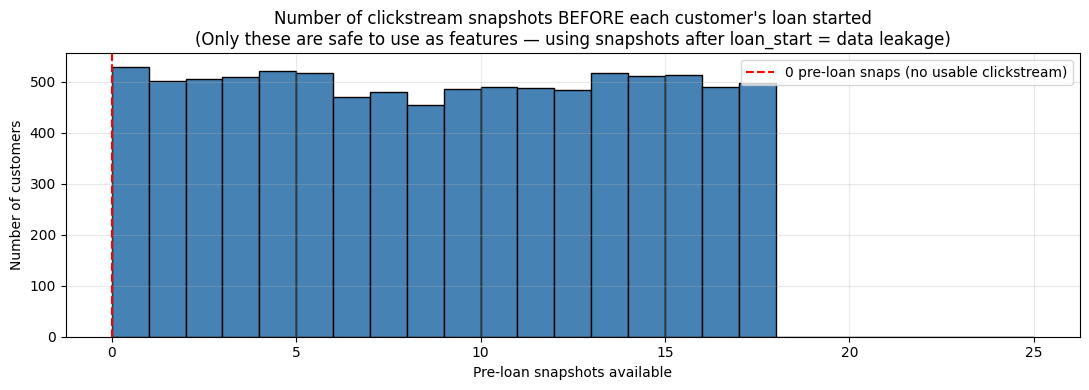

In [31]:
# Get each customer's loan_start_date (1 per customer)
loan_starts = loans.select("Customer_ID", "loan_start_date").distinct()

# Join clickstream with loan start date
ck_with_loan = clickstream.join(loan_starts, "Customer_ID", "inner") \
    .withColumn("is_pre_loan", F.col("snapshot_date") < F.col("loan_start_date")) \
    .withColumn("days_to_loan", F.datediff(F.col("loan_start_date"), F.col("snapshot_date")))

# Per-customer: how many snapshots are pre-loan?
per_cust = ck_with_loan.groupBy("Customer_ID") \
    .agg(
        F.sum(F.col("is_pre_loan").cast("int")).alias("pre_loan_snaps"),
        F.count("*").alias("total_snaps")
    )

print("=== Per-customer PRE-LOAN snapshot count ===")
per_cust.select("pre_loan_snaps").describe().show()

print("\n=== Distribution of pre-loan snapshot counts ===")
per_cust.groupBy("pre_loan_snaps").count().orderBy("pre_loan_snaps").show(30)

print("\n=== Visualization ===")
pdf = per_cust.select("pre_loan_snaps").toPandas()
plt.figure(figsize=(11, 4))
plt.hist(pdf["pre_loan_snaps"], bins=range(0, 26), edgecolor='black', color='steelblue')
plt.title("Number of clickstream snapshots BEFORE each customer's loan started\n(Only these are safe to use as features — using snapshots after loan_start = data leakage)")
plt.xlabel("Pre-loan snapshots available")
plt.ylabel("Number of customers")
plt.axvline(0, color='red', linestyle='--', label='0 pre-loan snaps (no usable clickstream)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
import glob
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression

# Load gold feature store + label store
features = spark.read.parquet(*sorted(glob.glob("datamart/gold/feature_store/*")))
labels   = spark.read.parquet(*sorted(glob.glob("datamart/gold/label_store/*")))

# Join on Customer_ID
data = features.join(labels.select("Customer_ID", "label"), "Customer_ID", "inner")

# Drop non-numeric/non-feature columns
drop_cols = ["Customer_ID", "loan_start_date", "snapshot_date", "Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]
feature_cols = [c for c, t in data.dtypes if c not in drop_cols and c != "label" and t in ("int", "bigint", "float", "double")]
print(f"Using {len(feature_cols)} numeric features")

# Drop nulls (simple model — no imputation)
data_clean = data.select(*feature_cols, "label").dropna()
print(f"After dropna: {data_clean.count()} rows")

# Fit logistic regression
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(data_clean).select("features", "label")
model = LogisticRegression(maxIter=20).fit(train_data)

# Quick AUC (on training data — not a real eval, just a "does it run" check)
preds = model.transform(train_data)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
auc = BinaryClassificationEvaluator(labelCol="label").evaluate(preds)
print(f"Training AUC: {auc:.4f}")

Using 48 numeric features


After dropna: 6518 rows


Training AUC: 0.8693
